# Решение задачи классификации рускоязычных отзывов
## Категории отзывов: positive/neutral/negative
## Ссылка на задачу с hugging face: https://huggingface.co/datasets/ai-forever/ru-reviews-classification



---



# 1: Загрузка и предварительный анализ данных

## 1.1: Импорт библиотек и загрузка датасета (убедимся, что датасет доступен)

In [ ]:
!pip install datasets transformers evaluate scikit-learn matplotlib seaborn pandas torch seqeval # Добавлены pandas, torch для явной установки, seqeval для метрик


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=092911fbe79fe0e2da81ef1b219193f0ec0cb5e9aed2dd60f02fb0482c9cebbc
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
import numpy as np
import evaluate
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Определение устройства (GPU/CPU) должно быть в самом начале
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Имя предобученной модели/токенизатора
model_checkpoint = "DeepPavlov/rubert-base-cased"

print("Библиотеки импортированы и устройство определено.")

Используемое устройство: cuda
Библиотеки импортированы и устройство определено.


In [ ]:
# Если датасет уже был загружен, этот шаг просто повторно загрузит его или использует кэшированную версию.
# Это безопасно и гарантирует, что переменная 'dataset' доступна.
dataset = load_dataset("ai-forever/ru-reviews-classification")

print("Датасет успешно загружен.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/111 [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl:   0%|          | 0.00/4.45M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15000 [00:00<?, ? examples/s]

Датасет успешно загружен.


## 1.2: Количество примеров в каждой выборке

In [ ]:
print("Краткий обзор данных: Количество примеров в каждой выборке")
print("---------------------------------------------------------")

# Выводим количество примеров для каждой выборки
print(f"Обучающая выборка (train): {len(dataset['train'])} примеров")
print(f"Валидационная выборка (validation): {len(dataset['validation'])} примеров")
print(f"Тестовая выборка (test): {len(dataset['test'])} примеров")

Краткий обзор данных: Количество примеров в каждой выборке
---------------------------------------------------------
Обучающая выборка (train): 45000 примеров
Валидационная выборка (validation): 15000 примеров
Тестовая выборка (test): 15000 примеров


## 1.3: Структура данных и примеры с использованием `datasets`

In [ ]:
print("\nСтруктура данных: Посмотрим на первый пример из каждой выборки")
print("----------------------------------------------------------")

# Выводим первый пример из обучающей выборки
print("\nПервый пример из обучающей выборки (train):")
print(dataset['train'][0])

# Выводим первый пример из валидационной выборки
print("\nПервый пример из валидационной выборки (validation):")
print(dataset['validation'][0])

# Выводим первый пример из тестовой выборки
print("\nПервый пример из тестовой выборки (test):")
print(dataset['test'][0])

print("\nКаждый пример состоит из полей 'text' (строка отзыва) и 'label' (целочисленная метка класса).")


Структура данных: Посмотрим на первый пример из каждой выборки
----------------------------------------------------------

Первый пример из обучающей выборки (train):
{'text': 'всё пришло спасибо. только немного короче чем я ожидала\nтак всё супер', 'label_text': 'positive', 'label': 2, 'id': '64971'}

Первый пример из валидационной выборки (validation):
{'text': 'Отличные колготки, качество превосходные. Мягки и приятные к телу. Доставка до Кемерово очень быстрая заказала 27 октября забрала на почте 17 ноября. На фото 2 пары черные размер L коричневые M. На ротс 164 и вес 65 подошли. Буду покупать еще.', 'label_text': 'positive', 'label': 2, 'id': '64976'}

Первый пример из тестовой выборки (test):
{'text': 'Майка очень коротка, после стирки ещё сильнее села, к продавцу претензий нет)', 'label_text': 'negative', 'label': 0, 'id': '17467'}

Каждый пример состоит из полей 'text' (строка отзыва) и 'label' (целочисленная метка класса).


## 1.4: Преобразование в Pandas DataFrame для углубленного анализа


In [ ]:
# Преобразуем обучающую выборку в Pandas DataFrame
train_df = dataset['train'].to_pandas()

print("\nИнформация о DataFrame обучающей выборки:")
print("---------------------------------------")
print(train_df.info())

print("\nПервые 5 строк DataFrame обучающей выборки:")
print(train_df.head())

print("\nРаспределение меток (классов) в обучающей выборке:")
print(train_df['label'].value_counts())

print("\nПроцентное соотношение меток (классов) в обучающей выборке:")
print(train_df['label'].value_counts(normalize=True) * 100)


Информация о DataFrame обучающей выборки:
---------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        45000 non-null  object
 1   label_text  45000 non-null  object
 2   label       45000 non-null  int64 
 3   id          45000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.4+ MB
None

Первые 5 строк DataFrame обучающей выборки:
                                                text label_text  label     id
0  всё пришло спасибо. только немного короче чем ...   positive      2  64971
1  The color of the dress is not the same as in t...    neutral      1  34896
2  Заказывала белый цвет, пришёл какой то персико...    neutral      1  46253
3  Приятное к телу. Но в бюсте на размер больше. ...   negative      0  19034
4                Не пришла деньги через спор вернули    neutral      1  36063



🟢 Классы идеально сбалансированы в выборке

## 1.5: Анализ длины текстов


Статистика по длине текстов в обучающей выборке:
-----------------------------------------------
count    45000.00000
mean       133.22920
std        126.35763
min          1.00000
25%         54.00000
50%         94.00000
75%        167.00000
max       1000.00000
Name: text_length, dtype: float64


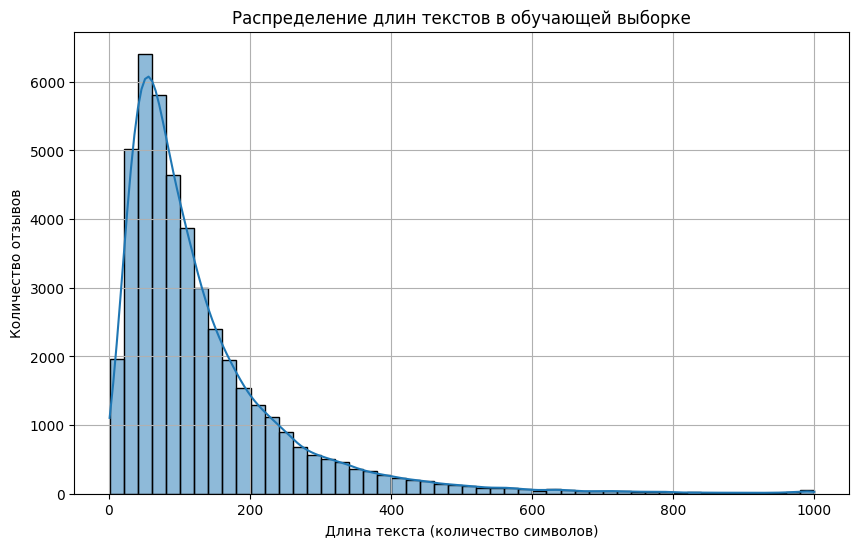


Пример самого длинного отзыва:
27.08. сделала заказ. Очень долго переписывалась с продавцом, продавец неохотно отвечал на мои сообщения трек не отслеживался я начала беспокоиться по этому вопросу. Продавец уверял меня что всё в порядке Не надо переживать что мой заказ уже отправлен что всё будет хорошо я его Скоро получу. Очень долго ждала как я уже говорила продавец отвечала на SMS неохотно очень долго После долгих длительных ожиданий и переписываться с продавцом которого я замучила просто своими сообщениями. Продавец предоставляет мне ответ что логистическая компания вернула товар и он может мне отправить повторно. Очень нечестный продавец Я считаю связываться с ним Не рекомендую. Вчера открыла спор и мне вернули деньги. продавца Не рекомендую здесь что-то заказывать. Сейчас я заказала куртку такую которую хотела конечно за другую цену но у другого продавца у которого очень хорошие отзывы и быстрая доставка. Надеюсь курткой буду довольна. и ещё хотелось бы отметить что очень очень о

In [ ]:
# Добавим колонку с длиной каждого отзыва
train_df['text_length'] = train_df['text'].apply(len)

print("\nСтатистика по длине текстов в обучающей выборке:")
print("-----------------------------------------------")
print(train_df['text_length'].describe())

# Построим гистограмму распределения длин текстов
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_length'], bins=50, kde=True)
plt.title('Распределение длин текстов в обучающей выборке')
plt.xlabel('Длина текста (количество символов)')
plt.ylabel('Количество отзывов')
plt.grid(True)
plt.show()

print("\nПример самого длинного отзыва:")
print(train_df.loc[train_df['text_length'].idxmax(), 'text'])

print("\nПример самого короткого отзыва:")
print(train_df.loc[train_df['text_length'].idxmin(), 'text'])

# 2: Предобработка данных (токенизация)

## 2.1: Выбор и инициализация токенизатора


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
print(f"Токенизатор '{model_checkpoint}' успешно загружен.")
print(f"\nРазмер словаря токенизатора: {tokenizer.vocab_size}")
print(f"Токен для начала последовательности (CLS): {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"Токен для разделения последовательностей (SEP): {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")
print(f"Токен для заполнения (PAD): {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"Токен для неизвестных слов (UNK): {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Токенизатор 'DeepPavlov/rubert-base-cased' успешно загружен.

Размер словаря токенизатора: 119547
Токен для начала последовательности (CLS): [CLS] (ID: 101)
Токен для разделения последовательностей (SEP): [SEP] (ID: 102)
Токен для заполнения (PAD): [PAD] (ID: 0)
Токен для неизвестных слов (UNK): [UNK] (ID: 100)


## 2.2: Тестирование токенизатора на примере

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
print(f"Токенизатор '{model_checkpoint}' успешно загружен.")
print(f"\nРазмер словаря токенизатора: {tokenizer.vocab_size}")
print(f"Токен для начала последовательности (CLS): {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"Токен для разделения последовательностей (SEP): {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")
print(f"Токен для заполнения (PAD): {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"Токен для неизвестных слов (UNK): {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")

Токенизатор 'DeepPavlov/rubert-base-cased' успешно загружен.

Размер словаря токенизатора: 119547
Токен для начала последовательности (CLS): [CLS] (ID: 101)
Токен для разделения последовательностей (SEP): [SEP] (ID: 102)
Токен для заполнения (PAD): [PAD] (ID: 0)
Токен для неизвестных слов (UNK): [UNK] (ID: 100)


## 2.3: Применение токенизации ко всему датасету

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',  # всегда до max_length
        max_length=512         # максимум для BERT
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels") # Переименование для Trainer
tokenized_datasets.set_format("torch") # Установка формата PyTorch

print("\nДатасет успешно токенизирован и подготовлен для Trainer.")
print(tokenized_datasets)
print("\nПример токенизированного элемента из обучающей выборки:")
print(tokenized_datasets['train'][0])

Map:   0%|          | 0/45000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]


Датасет успешно токенизирован и подготовлен для Trainer.
DatasetDict({
    train: Dataset({
        features: ['label_text', 'labels', 'id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 45000
    })
    validation: Dataset({
        features: ['label_text', 'labels', 'id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['label_text', 'labels', 'id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
})

Пример токенизированного элемента из обучающей выборки:
{'label_text': 'positive', 'labels': tensor(2), 'id': '64971', 'input_ids': tensor([   101,  10235,  30864, 107685,    132,   4564,  17042,  38792,   3622,
           877, 102826,   2306,  10235,  23521,    102,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,

# 3: Выбор и подготовка модели

## 3.1: Выбор и инициализация предобученной модели

In [ ]:
num_labels = 3 # positive/neutral/negative
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)
model.to(device) # Перемещаем модель на GPU/CPU
print(f"Модель '{model_checkpoint}' для классификации последовательностей успешно загружена.")
print(f"Модель настроена на {num_labels} выходных классов.")
print("\nАрхитектура модели (последние слои):")
print(model.classifier)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель 'DeepPavlov/rubert-base-cased' для классификации последовательностей успешно загружена.
Модель настроена на 3 выходных классов.

Архитектура модели (последние слои):
Linear(in_features=768, out_features=3, bias=True)


## 3.2: Проверка модели на одном примере (опционально)

In [ ]:
example_input = {
    "input_ids": torch.tensor(tokenized_datasets['train'][0]['input_ids']).unsqueeze(0).to(device),
    "attention_mask": torch.tensor(tokenized_datasets['train'][0]['attention_mask']).unsqueeze(0).to(device)
}
print("\nВходные данные для модели (первый токенизированный пример):")
print(f"Input IDs shape: {example_input['input_ids'].shape}")
print(f"Attention Mask shape: {example_input['attention_mask'].shape}")

model.eval()
with torch.no_grad():
    outputs = model(**example_input)

print("\nВыходные данные модели:")
print(outputs)
logits = outputs.logits
print(f"\nЛогиты (предсказания до Softmax): {logits}")
print(f"Форма логитов: {logits.shape}")
probabilities = torch.softmax(logits, dim=1)
print(f"\nВероятности классов: {probabilities}")
predicted_class_id = torch.argmax(probabilities, dim=1).item()
print(f"\nПредсказанный ID класса: {predicted_class_id}")
model.train() # Возвращаем модель в режим тренировки


Входные данные для модели (первый токенизированный пример):
Input IDs shape: torch.Size([1, 512])
Attention Mask shape: torch.Size([1, 512])


/tmp/ipython-input-3443536517.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "input_ids": torch.tensor(tokenized_datasets['train'][0]['input_ids']).unsqueeze(0).to(device),
/tmp/ipython-input-3443536517.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(tokenized_datasets['train'][0]['attention_mask']).unsqueeze(0).to(device)



Выходные данные модели:
SequenceClassifierOutput(loss=None, logits=tensor([[ 0.1070, -0.0270,  0.2349]], device='cuda:0'), hidden_states=None, attentions=None)

Логиты (предсказания до Softmax): tensor([[ 0.1070, -0.0270,  0.2349]], device='cuda:0')
Форма логитов: torch.Size([1, 3])

Вероятности классов: tensor([[0.3321, 0.2905, 0.3774]], device='cuda:0')

Предсказанный ID класса: 2


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

# 4: Обучение модели

## 4.1: Определение метрик оценки

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='weighted') # weighted для 3 классов
    return {"accuracy": accuracy["accuracy"], "f1": f1["f1"]}

print("Функция для вычисления метрик определена.")

Функция для вычисления метрик определена.


## 4.2: Определение аргументов обучения (TrainingArguments)

In [ ]:
output_dir = "./results"

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,
    logging_dir='./logs',
    logging_steps=100,
    report_to="none",
)

## 4.3: Инициализация Trainer и запуск обучения

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-3893836303.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()
print("\nОбучение завершено!")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.561000,0.533894,0.771000,0.773870
2,0.477500,0.543964,0.775133,0.776940
3,0.365500,0.607150,0.769267,0.771246


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.561000,0.533894,0.771000,0.773870
2,0.477500,0.543964,0.775133,0.776940
3,0.365500,0.607150,0.769267,0.771246



Обучение завершено!


# 5: Оценка модели

## 5.1: Оценка модели на тестовой выборке

In [ ]:
print("Запускаем оценку модели на тестовой выборке...")
test_results = trainer.evaluate(tokenized_datasets["test"])
print("\nРезультаты оценки на тестовой выборке:")
print(test_results)

Запускаем оценку модели на тестовой выборке...



Результаты оценки на тестовой выборке:
{'eval_loss': 0.5461279153823853, 'eval_accuracy': 0.7671333333333333, 'eval_f1': 0.7686536846351507, 'eval_runtime': 422.6305, 'eval_samples_per_second': 35.492, 'eval_steps_per_second': 2.219, 'epoch': 3.0}


## 5.2: Дополнительный анализ: матрица ошибок (Confusion Matrix) и отчет о классификации


Дополнительный анализ: Матрица ошибок и отчет о классификации...


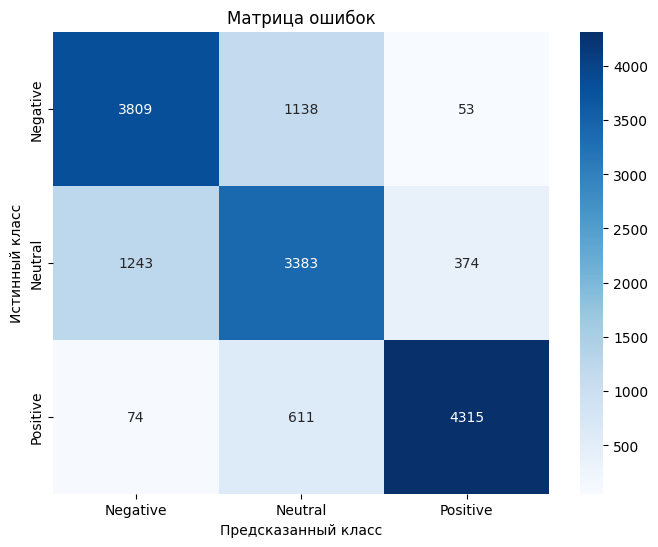


Отчет о классификации:
              precision    recall  f1-score   support

    Negative       0.74      0.76      0.75      5000
     Neutral       0.66      0.68      0.67      5000
    Positive       0.91      0.86      0.89      5000

    accuracy                           0.77     15000
   macro avg       0.77      0.77      0.77     15000
weighted avg       0.77      0.77      0.77     15000



In [ ]:
print("\nДополнительный анализ: Матрица ошибок и отчет о классификации...")
predictions_output = trainer.predict(tokenized_datasets["test"])
logits = predictions_output.predictions
true_labels = predictions_output.label_ids
predicted_labels = np.argmax(logits, axis=-1)

# Матрица ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(true_labels, predicted_labels),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок")
plt.show()

# Отчет о классификации
print("\nОтчет о классификации:")
print(classification_report(true_labels, predicted_labels,
                            target_names=["Negative", "Neutral", "Positive"]))

# 6: Сохранение модели и подготовка пайплайна

## 6.1: Сохранение обученной модели и токенизатора ---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# Путь на Google Drive
final_model_path = "/content/drive/MyDrive/Colab Notebooks/models/nlp_reviews_classification/final_sentiment_model"

os.makedirs(final_model_path, exist_ok=True)

# Сохраняем модель и токенизатор
trainer.save_model(final_model_path)
print(f"\nОбученная модель и токенизатор сохранены в: {final_model_path}")


## 6.2: Загрузка сохраненной модели и токенизатора для использования ---

In [ ]:
print("\n--- Подготовка пайплайна для предсказаний ---")

loaded_tokenizer = AutoTokenizer.from_pretrained(final_model_path)
loaded_model = AutoModelForSequenceClassification.from_pretrained(final_model_path, num_labels=3)
loaded_model.to(device)
loaded_model.eval() # Обязательно для инференса

# Словарь для преобразования числовых меток в читаемые названия классов
id_to_label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

# --- Использование pipeline для удобных предсказаний ---
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    device=0 if torch.cuda.is_available() else -1, # 0 для GPU, -1 для CPU
    return_all_scores=True # Чтобы получить вероятности всех классов
)

print("\nПайплайн для анализа тональности инициализирован.")

# 7: Использование модели для предсказаний с пайплайном

## 7.1: Функция для предсказания тональности одного отзыва

In [ ]:
def predict_sentiment_with_pipeline(text):
    result = sentiment_analyzer(text)[0]
    best_result = max(result, key=lambda x: x['score'])

    # Извлекаем числовой ID из 'LABEL_X' и сопоставляем с нашим словарем
    label_id = int(best_result['label'].split('_')[1])
    predicted_label = id_to_label[label_id]
    predicted_probability = best_result['score']

    return predicted_label, predicted_probability

print("Функция predict_sentiment_with_pipeline определена.")

## 7.2: Тестирование модели на новых отзывах

In [ ]:
new_reviews = [
    "Отличный сервис, мне очень понравилось!",
    "Ужасное качество товара, крайне недоволен покупкой.",
    "Все вроде бы хорошо, но есть пара недочетов. В целом, нормально.",
    "Неплохо, но ожидал большего. Доставка была быстрой.",
    "Мне кажется, это лучший продукт в своей категории!",
    "Полная ерунда, больше никогда не куплю."
]

print("\nПредсказания для новых отзывов (с использованием пайплайна):")
print("---------------------------------------------------------")

for i, review in enumerate(new_reviews):
    predicted_label, probability = predict_sentiment_with_pipeline(review)
    print(f"Отзыв {i+1}: \"{review}\"")
    print(f"  Предсказанная тональность: {predicted_label} (Вероятность: {probability:.4f})")
    print("-" * 30)

print("\nПроект решения задачи по NLP ai-forever/ru-reviews-classification полностью завершен!")